## <div align="center"> LAB IS411 Data Modelling </div>
## <div align="center"> [UTS] Child Malnutrition Analysis</div>
#### <div align="center"> Even Semester 2025/2026 </div>

---

**Anggota Kelompok:**
- [Patricia Felisca Clarrisya | 00000117495]
- [Lovely Sayungki | 00000121376]
- [Evan Marcello Sabastian | 00000122364]

**Kelas:** BL

---

### 1. Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)
%matplotlib inline

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("Child_Malnutrition_with_Socioeconomic_Factors_dataset.csv")

print("=== DATASET OVERVIEW ===")
print(f"Jumlah baris    : {df.shape[0]}")
print(f"Jumlah kolom    : {df.shape[1]}")
print(f"Jumlah negara   : {df['Country'].nunique()}")
print(f"Rentang tahun   : {df['Year'].min()} - {df['Year'].max()}\n")
print("Distribusi Stunting_Risk:")
print(df['Stunting_Risk'].value_counts())

=== DATASET OVERVIEW ===
Jumlah baris    : 307
Jumlah kolom    : 13
Jumlah negara   : 77
Rentang tahun   : 2000 - 2023

Distribusi Stunting_Risk:
Stunting_Risk
0    203
1     52
2     52
Name: count, dtype: int64


Penjelasan:
Dataset ini berisi 307 observasi dari 77 negara (tahun 2000–2023). Variabel target Stunting_Risk memiliki 3 kelas (0 = Rendah, 1 = Sedang, 2 = Tinggi) dan bersifat imbalanced.

###  2. Dataset Overview, Data Cleansing & Handling Missing Values

In [3]:
print("--- Column Info ---")
df.info()

numeric_cols = ['Stunting_Prevalence', 'Overweight_Prevalence', 'GDP_per_Capita',
                'Poverty_Rate', 'Male_Literacy_Rate', 'Female_Literacy_Rate',
                'Fertility_Rate', 'Urban_Population_Percent']

--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   307 non-null    object 
 1   ISO3                      307 non-null    object 
 2   Year                      307 non-null    int64  
 3   Stunting_Prevalence       307 non-null    float64
 4   Overweight_Prevalence     307 non-null    float64
 5   Stunting_Risk             307 non-null    int64  
 6   Overweight_Risk           307 non-null    int64  
 7   GDP_per_Capita            307 non-null    float64
 8   Poverty_Rate              307 non-null    float64
 9   Fertility_Rate            307 non-null    float64
 10  Urban_Population_Percent  307 non-null    float64
 11  Female_Literacy_Rate      307 non-null    float64
 12  Male_Literacy_Rate        307 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usa

In [4]:
df.head(10)

,Country,ISO3,Year,Stunting_Prevalence,Overweight_Prevalence,Stunting_Risk,Overweight_Risk,GDP_per_Capita,Poverty_Rate,Fertility_Rate,Urban_Population_Percent,Female_Literacy_Rate,Male_Literacy_Rate
0,Albania,ALB,2008,22.8,24.1,1,1,4498.504868,0.8,1.616,49.385070,94.680000,97.309998
1,Albania,ALB,2012,16.5,20.9,0,1,4280.933163,1.8,1.719,53.863755,96.139999,98.349998
2,Albania,ALB,2017,12.0,16.1,0,1,5006.360130,1.4,1.486,55.980276,99.050003,98.570000
3,Argentina,ARG,2001,9.0,10.4,0,1,7141.475077,10.7,2.531,89.368295,97.190002,97.190002
4,Argentina,ARG,2020,8.8,12.4,0,1,8535.599380,2.2,1.601,91.943903,99.160004,99.129997
5,Armenia,ARM,2001,18.1,12.5,0,1,659.588989,24.1,1.200,64.822812,99.160004,99.669998
6,Armenia,ARM,2011,15.4,15.1,0,1,3349.553098,3.1,1.500,64.320745,99.690002,99.809998
7,Armenia,ARM,2016,10.6,13.2,0,1,3524.424769,2.5,1.600,64.592875,99.690002,99.809998
8,Armenia,ARM,2017,9.7,12.9,0,1,3869.053739,2.4,1.600,64.712495,99.680000,99.809998
9,Armenia,ARM,2020,7.5,12.2,0,1,4268.680933,1.5,1.700,65.174217,99.739998,99.839996


Penjelasan:
Data menunjukkan distribusi right-skewed pada beberapa variabel (misalnya Poverty Rate dan Fertility Rate). Stunting_Prevalence memiliki variasi yang tinggi antar negara.

In [5]:
# Cek Missing Value
missing_counts = df.isnull().sum()
if missing_counts.sum() > 0:
    df = df.dropna()
    print("-> Missing values ditemukan dan dihapus.")
else:
    print("-> Data Bersih dari Missing values.")

-> Data Bersih dari Missing values.


### 3. EDA - Statistical Description & Correlation

In [6]:
print("=== BASIC DESCRIPTIVE STATISTICS ===")
print(df[numeric_cols].describe().round(3))

ext_stats = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Std Dev': df[numeric_cols].std(),
    'Skewness': df[numeric_cols].skew(),
    'Kurtosis': df[numeric_cols].kurtosis()
}).round(3)
print("\n=== EXTENDED STATISTICS ===")
print(ext_stats)

# Correlation dengan target
corr = df[numeric_cols + ['Stunting_Risk']].corr()['Stunting_Risk'].sort_values(ascending=False)
print("\n=== CORRELATION DENGAN STUNTING_RISK ===")
print(corr.round(4))

=== BASIC DESCRIPTIVE STATISTICS ===
       Stunting_Prevalence  Overweight_Prevalence  GDP_per_Capita  \
count              307.000                307.000         307.000   
mean                17.816                  7.358        5917.484   
std                 12.409                  3.497        4839.086   
min                  1.300                  0.600         133.170   
25%                  8.050                  5.100        2430.947   
50%                 13.600                  7.200        4993.515   
75%                 25.000                  9.200        7802.607   
max                 56.800                 24.100       29425.457   

       Poverty_Rate  Male_Literacy_Rate  Female_Literacy_Rate  Fertility_Rate  \
count       307.000             307.000               307.000         307.000   
mean         15.104              89.738                85.251           2.598   
std          19.547              12.994                19.203           1.241   
min           0.0

### 4. EDA - Correlation

=== CORRELATION DENGAN STUNTING_RISK ===
Stunting_Risk               1.0000
Stunting_Prevalence         0.9215
Poverty_Rate                0.7234
Fertility_Rate              0.7003
Overweight_Prevalence      -0.4160
GDP_per_Capita             -0.5301
Male_Literacy_Rate         -0.5657
Female_Literacy_Rate       -0.6112
Urban_Population_Percent   -0.6711
Name: Stunting_Risk, dtype: float64


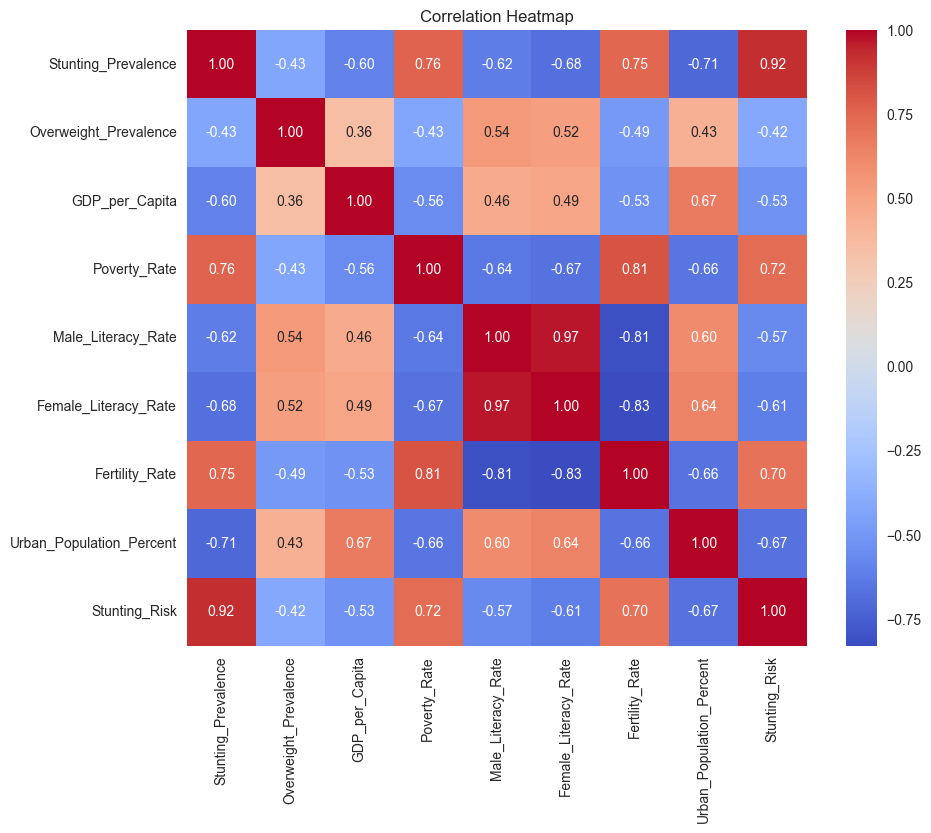

In [7]:
corr = df[numeric_cols + ['Stunting_Risk']].corr()['Stunting_Risk'].sort_values(ascending=False)
print("=== CORRELATION DENGAN STUNTING_RISK ===")
print(corr.round(4))

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols + ['Stunting_Risk']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Interpretasi :

Stunting_Prevalence memiliki korelasi sangat kuat (+0.9215) → paling dominan.
Faktor risiko: Poverty Rate (+0.7234) dan Fertility Rate (+0.7003).
Faktor protektif: Female Literacy Rate (-0.6112), Urban Population (-0.6711), GDP per Capita (-0.5301).

### 5. EDA -  Visualizations 

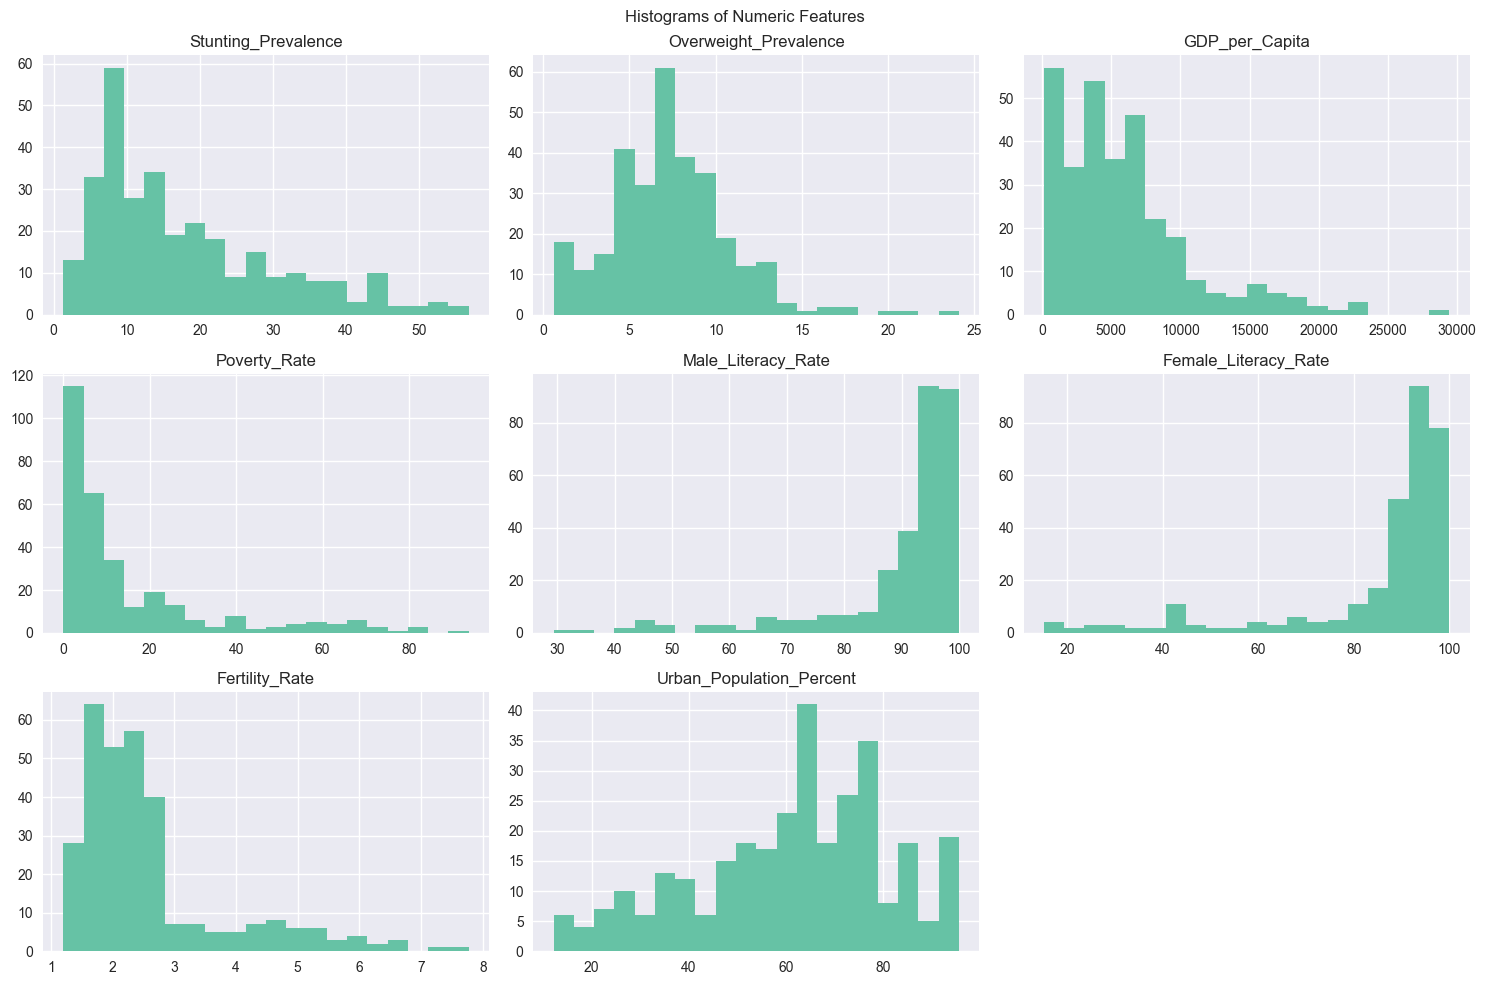

In [8]:
# 1. Histogram untuk semua fitur numerik
df[numeric_cols].hist(bins=20, figsize=(15, 10))
plt.suptitle('Histograms of Numeric Features')
plt.tight_layout()
plt.show()

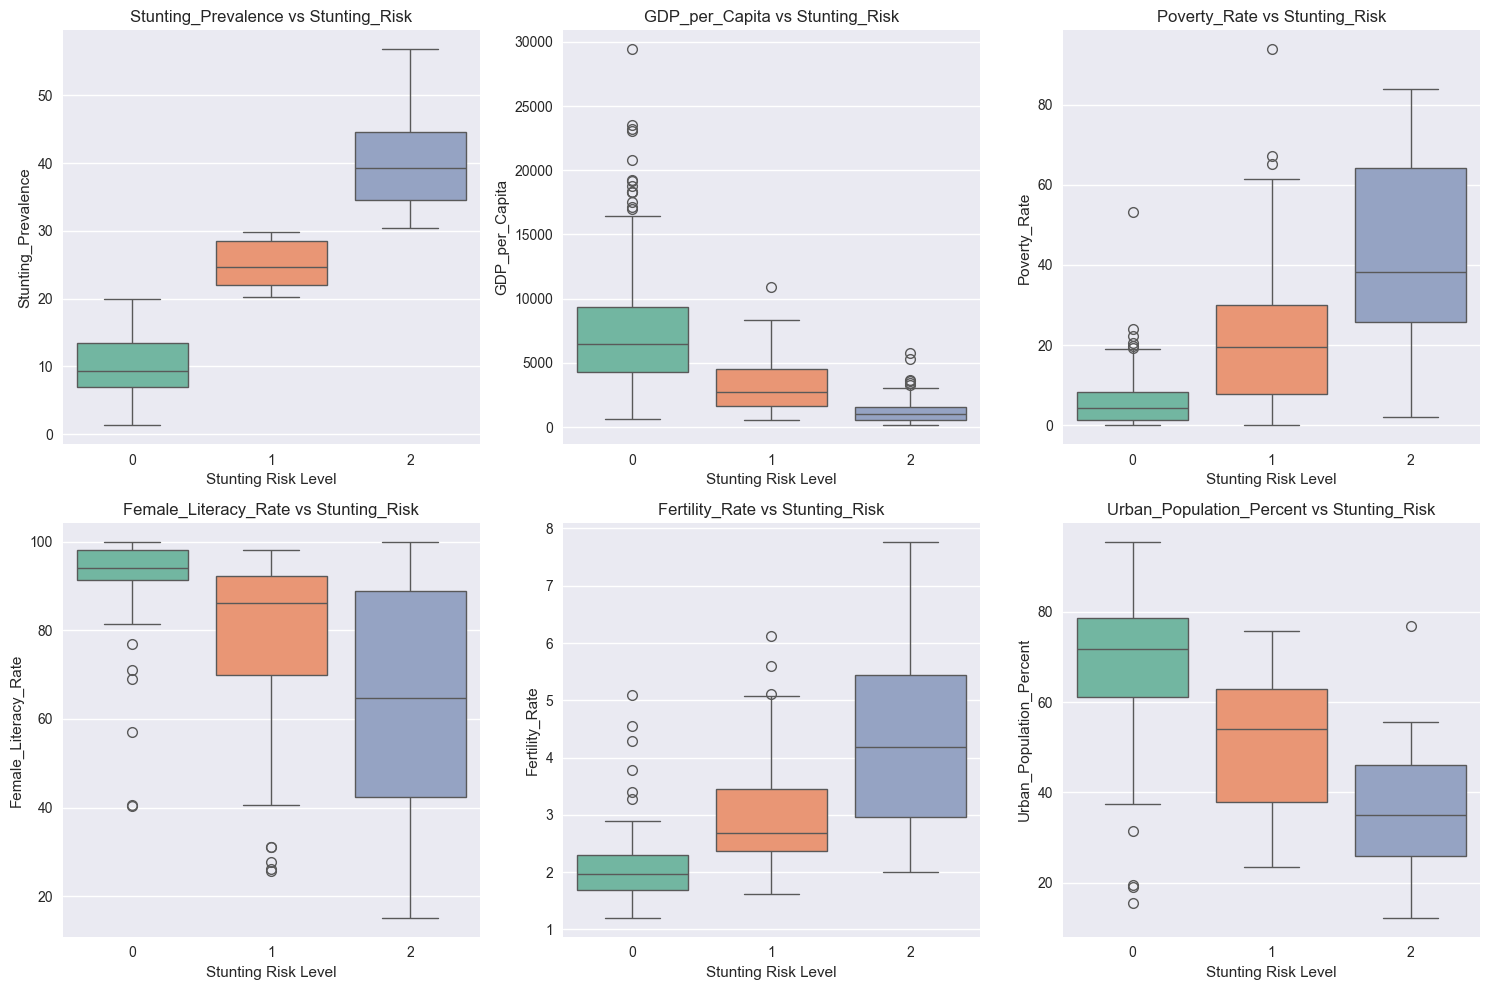

In [9]:
# 2. Boxplot
features_to_plot = ['Stunting_Prevalence', 'GDP_per_Capita', 'Poverty_Rate', 
                    'Female_Literacy_Rate', 'Fertility_Rate', 'Urban_Population_Percent']

plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x='Stunting_Risk', y=col, palette='Set2')
    plt.title(f'{col} vs Stunting_Risk')
    plt.xlabel('Stunting Risk Level')

plt.tight_layout()
plt.show()

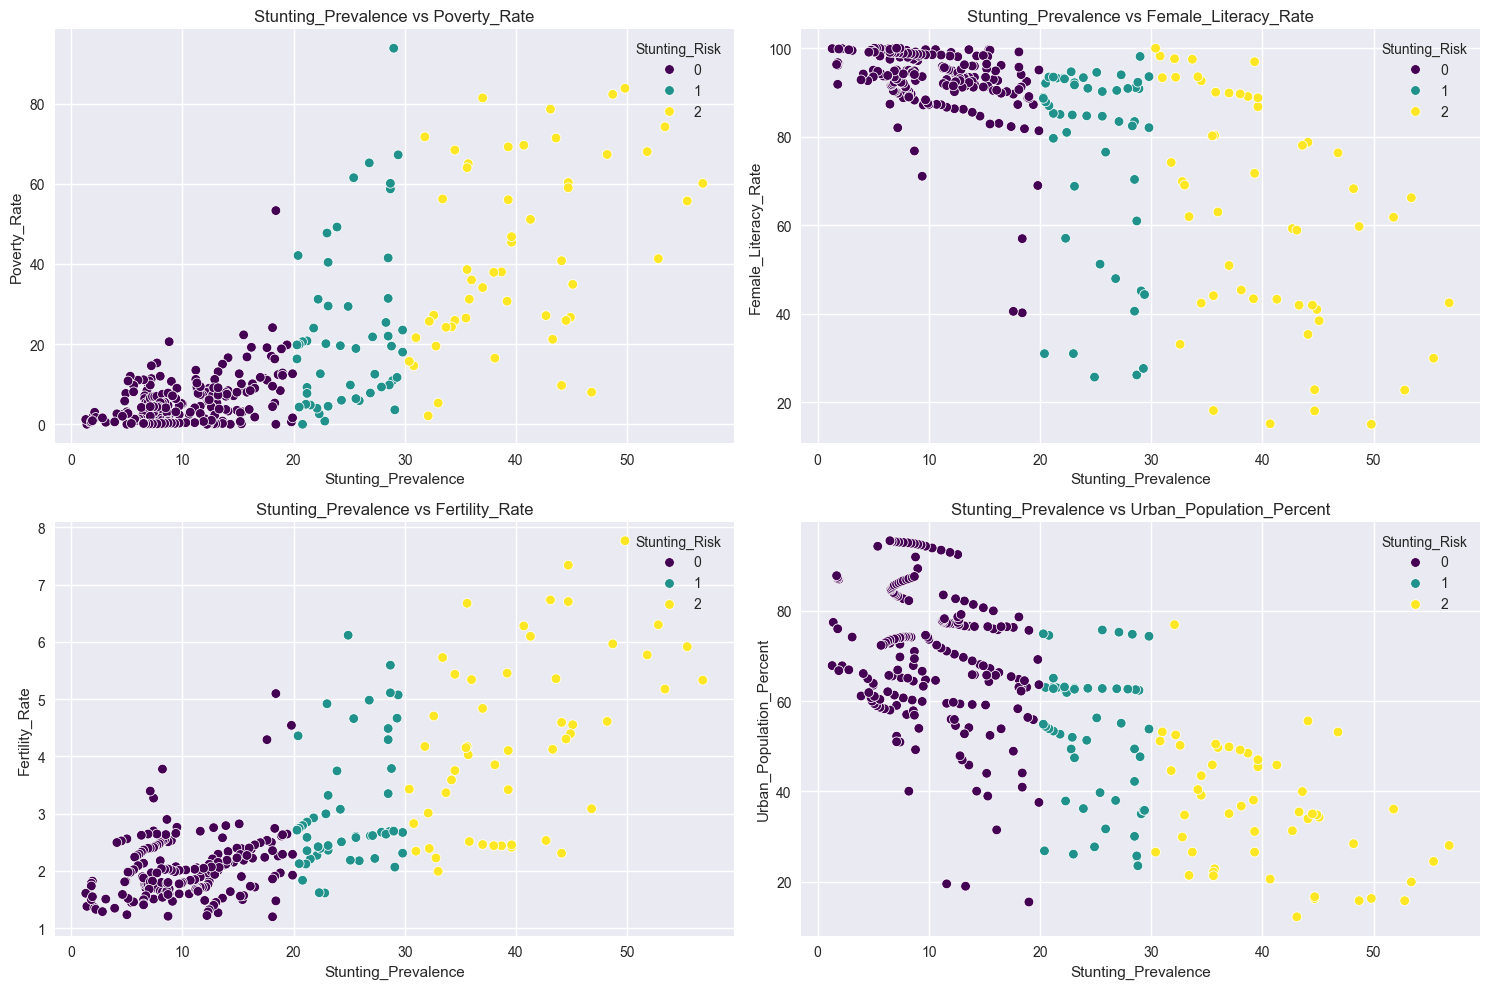

In [10]:
# 3. Scatter Plot untuk fitur paling berkorelasi
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='Stunting_Prevalence', y='Poverty_Rate', hue='Stunting_Risk', palette='viridis')
plt.title('Stunting_Prevalence vs Poverty_Rate')

plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='Stunting_Prevalence', y='Female_Literacy_Rate', hue='Stunting_Risk', palette='viridis')
plt.title('Stunting_Prevalence vs Female_Literacy_Rate')

plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='Stunting_Prevalence', y='Fertility_Rate', hue='Stunting_Risk', palette='viridis')
plt.title('Stunting_Prevalence vs Fertility_Rate')

plt.subplot(2, 2, 4)
sns.scatterplot(data=df, x='Stunting_Prevalence', y='Urban_Population_Percent', hue='Stunting_Risk', palette='viridis')
plt.title('Stunting_Prevalence vs Urban_Population_Percent')

plt.tight_layout()
plt.show()

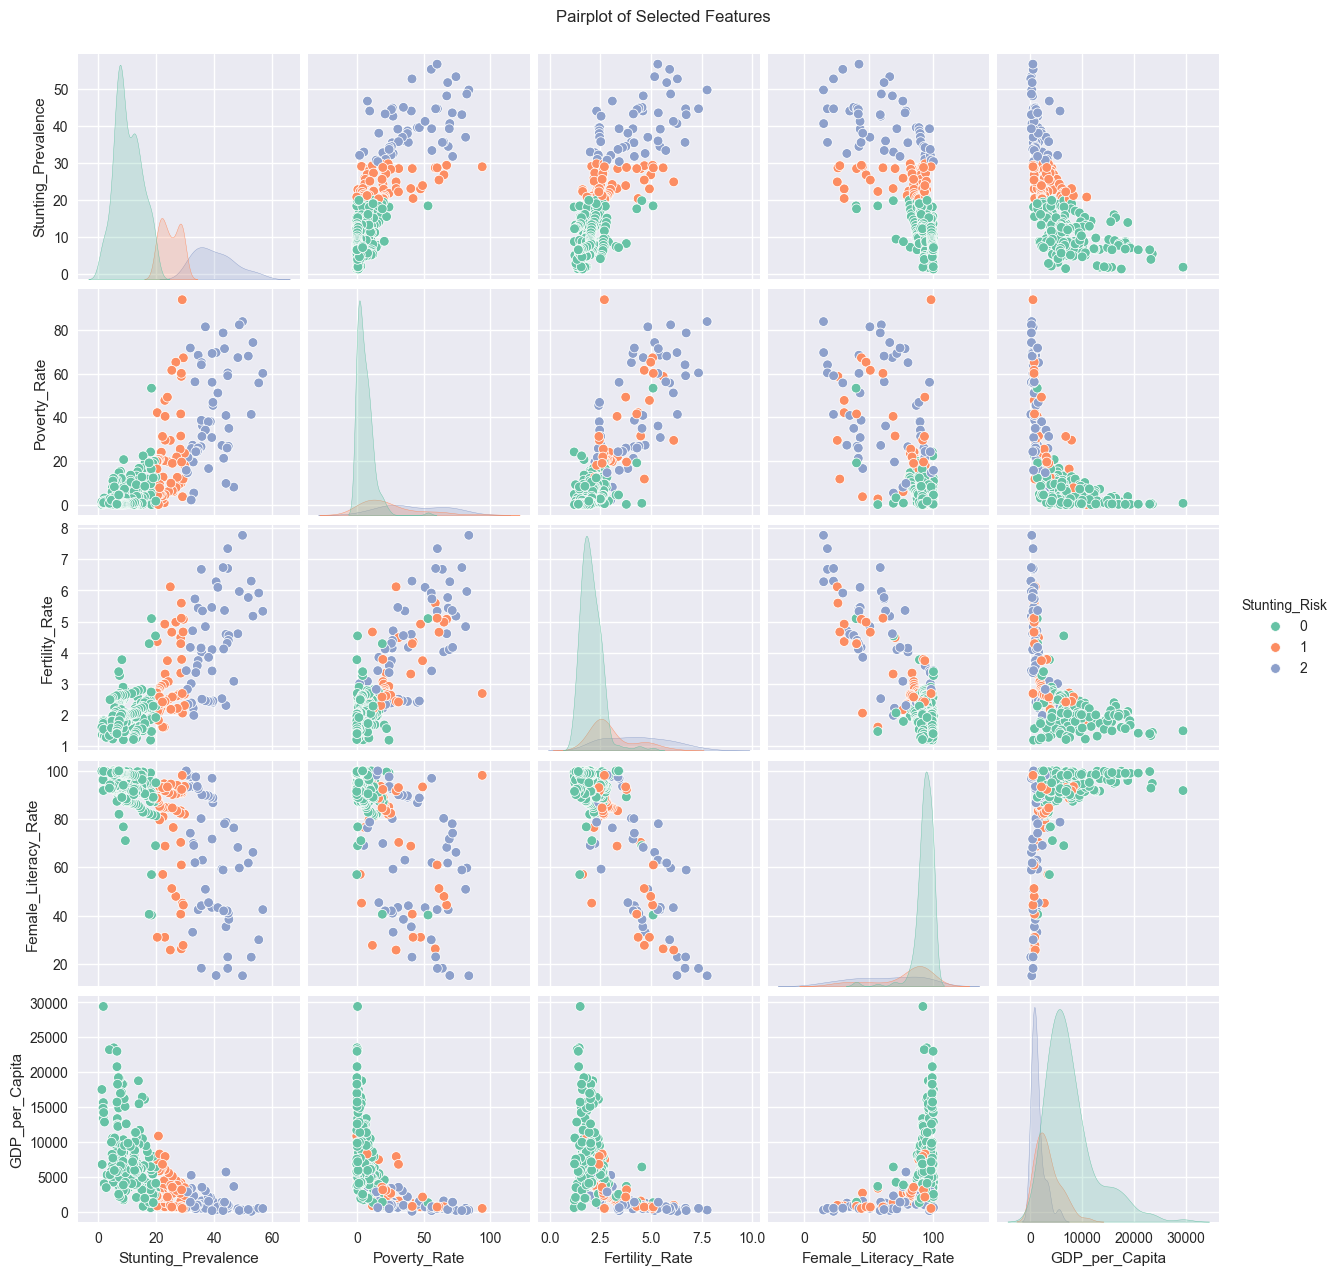

In [11]:
# 4. Pairplot (selected feature)

selected_for_pair = ['Stunting_Prevalence', 'Poverty_Rate', 'Fertility_Rate', 
                     'Female_Literacy_Rate', 'GDP_per_Capita', 'Stunting_Risk']

sns.pairplot(df[selected_for_pair], hue='Stunting_Risk', diag_kind='kde', palette='Set2')
plt.suptitle('Pairplot of Selected Features', y=1.02)
plt.show()

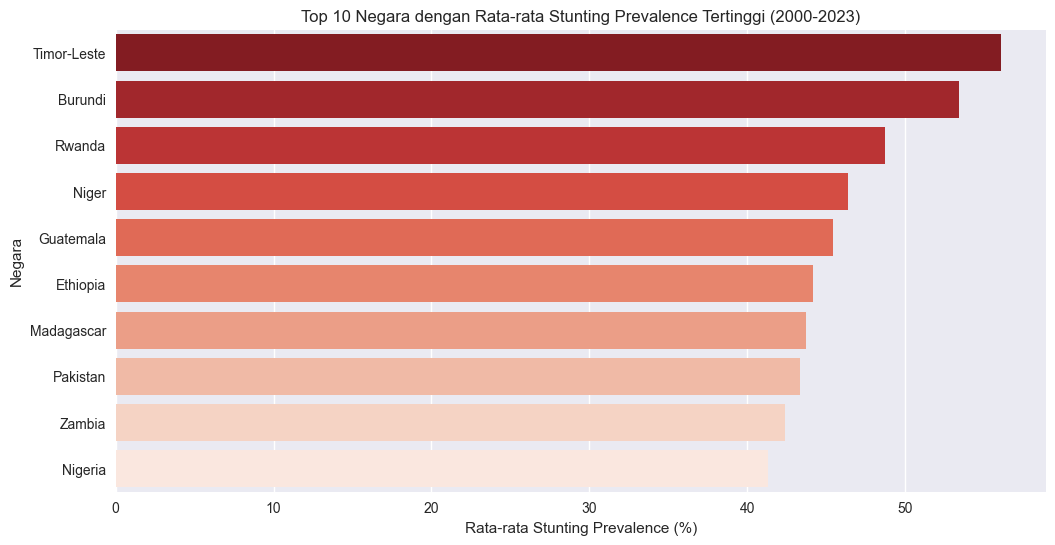

Top 10 Negara dengan Stunting Tertinggi:
Country
Timor-Leste    56.10
Burundi        53.40
Rwanda         48.70
Niger          46.40
Guatemala      45.45
Ethiopia       44.20
Madagascar     43.75
Pakistan       43.33
Zambia         42.40
Nigeria        41.30
Name: Stunting_Prevalence, dtype: float64


In [12]:
# 6. Top 10 Negara dengan Stunting tertinggi
plt.figure(figsize=(12, 6))
top_countries = df.groupby('Country')['Stunting_Prevalence'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')
plt.title('Top 10 Negara dengan Rata-rata Stunting Prevalence Tertinggi (2000-2023)')
plt.xlabel('Rata-rata Stunting Prevalence (%)')
plt.ylabel('Negara')
plt.show()

print("Top 10 Negara dengan Stunting Tertinggi:")
print(top_countries.round(2))

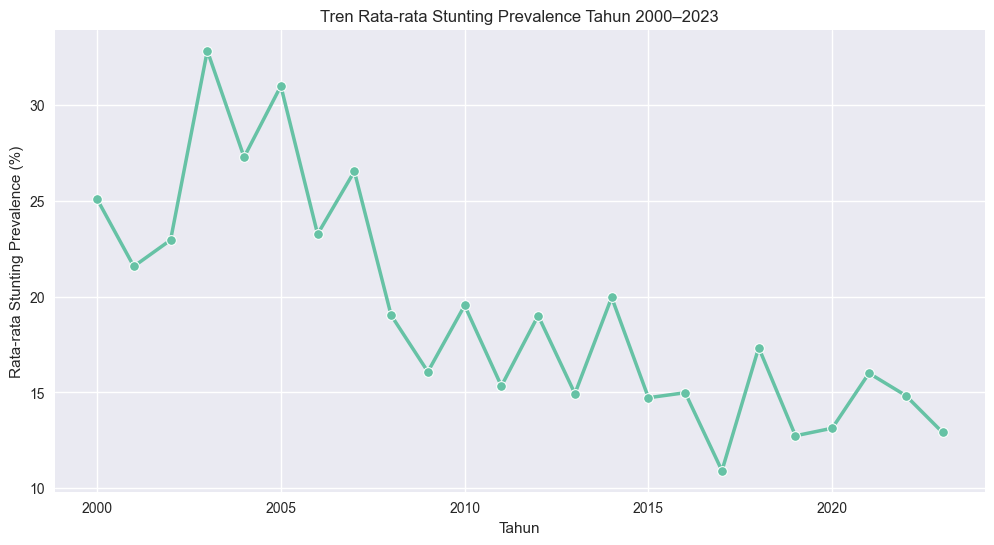

Rata-rata Stunting Prevalence per Tahun:
Year
2000    25.10
2001    21.58
2002    22.96
2003    32.84
2004    27.28
2005    31.00
2006    23.27
2007    26.54
2008    19.03
2009    16.08
2010    19.54
2011    15.34
2012    19.01
2013    14.94
2014    19.96
2015    14.73
2016    14.99
2017    10.92
2018    17.34
2019    12.74
2020    13.14
2021    16.01
2022    14.84
2023    12.92
Name: Stunting_Prevalence, dtype: float64


In [13]:
# 7. Tren Stunting Per Tahun
plt.figure(figsize=(12, 6))
yearly_trend = df.groupby('Year')['Stunting_Prevalence'].mean()

sns.lineplot(x=yearly_trend.index, y=yearly_trend.values, marker='o', linewidth=2.5)
plt.title('Tren Rata-rata Stunting Prevalence Tahun 2000–2023')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Stunting Prevalence (%)')
plt.grid(True)
plt.show()

print("Rata-rata Stunting Prevalence per Tahun:")
print(yearly_trend.round(2))

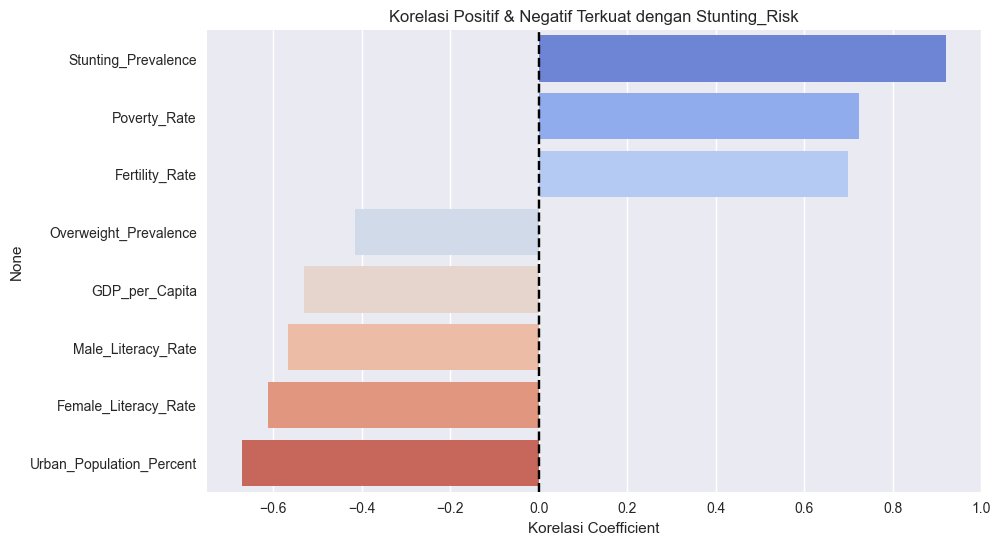

Top 5 Positive & Negative Correlation dengan Stunting_Risk:
Stunting_Prevalence         0.9215
Poverty_Rate                0.7234
Fertility_Rate              0.7003
Overweight_Prevalence      -0.4160
GDP_per_Capita             -0.5301
Male_Literacy_Rate         -0.5657
Female_Literacy_Rate       -0.6112
Urban_Population_Percent   -0.6711
Name: Stunting_Risk, dtype: float64


In [14]:
# 8. Top Correlation dengan Stunting Risk
corr_with_target = df[numeric_cols + ['Stunting_Risk']].corr()['Stunting_Risk'].drop('Stunting_Risk').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')
plt.title('Korelasi Positif & Negatif Terkuat dengan Stunting_Risk')
plt.xlabel('Korelasi Coefficient')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

print("Top 5 Positive & Negative Correlation dengan Stunting_Risk:")
print(corr_with_target.round(4))

### 6. Feature Engineering

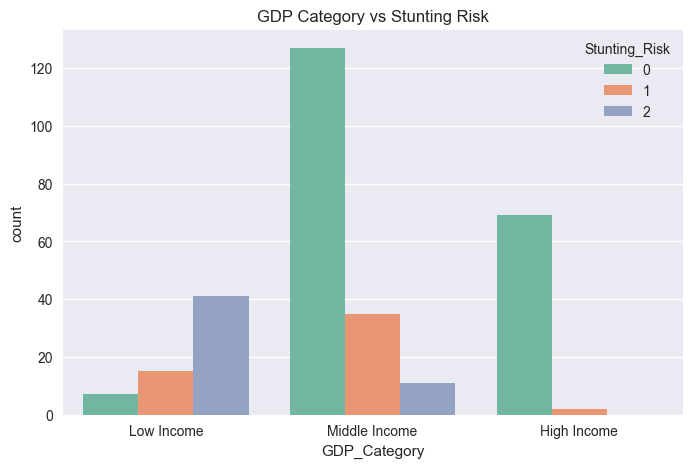


=== Feature Importance ===
Stunting_Prevalence         0.4593
Poverty_Rate                0.1221
Urban_Population_Percent    0.1121
GDP_per_Capita              0.1074
Fertility_Rate              0.0701
Male_Literacy_Rate          0.0507
Female_Literacy_Rate        0.0415
Overweight_Prevalence       0.0367
dtype: float64

Fitur terpilih: ['Stunting_Prevalence', 'Poverty_Rate', 'Urban_Population_Percent', 'GDP_per_Capita', 'Fertility_Rate', 'Male_Literacy_Rate']


In [15]:
# 1. Binning GDP_per_Capita
bins = [0, 2000, 8000, df['GDP_per_Capita'].max()]
labels = ['Low Income', 'Middle Income', 'High Income']
df['GDP_Category'] = pd.cut(df['GDP_per_Capita'], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='GDP_Category', hue='Stunting_Risk', palette='Set2')
plt.title('GDP Category vs Stunting Risk')
plt.show()

# 2. Feature Selection menggunakan Random Forest
X_temp = df[numeric_cols]
y = df['Stunting_Risk']

rf_selector = RandomForestClassifier(random_state=42)
rf_selector.fit(X_temp, y)

# Buat Series dengan index yang benar (numeric_cols)
importances = pd.Series(rf_selector.feature_importances_, index=numeric_cols).sort_values(ascending=False)

print("\n=== Feature Importance ===")
print(importances.round(4))

# Pilih fitur dengan importance > 0.05
selected_features = importances[importances > 0.05].index.tolist()
print("\nFitur terpilih:", selected_features)

# Update X dengan fitur terpilih
X = df[selected_features]

Penjelasan:
GDP_per_Capita dibagi menjadi 3 kategori (Low, Middle, High Income) untuk mempermudah interpretasi dan mengurangi noise dari nilai kontinu yang sangat bervariasi.

### 7. Splitting Dataset

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

print(f"Jumlah data training : {X_train.shape[0]}")
print(f"Jumlah data testing  : {X_test.shape[0]}")

Jumlah data training : 245
Jumlah data testing  : 62


### 8. Penanganan Ketidakseimbangan Data (SMOTE)

In [17]:
print("Distribusi kelas sebelum SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribusi kelas setelah SMOTE :", Counter(y_train_res))

Distribusi kelas sebelum SMOTE: Counter({0: 162, 2: 42, 1: 41})
Distribusi kelas setelah SMOTE : Counter({0: 162, 2: 162, 1: 162})


### 9. Modeling & Evaluation


=== HASIL MODELING ===

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       0.92      1.00      0.96        11
           2       1.00      0.90      0.95        10

    accuracy                           0.98        62
   macro avg       0.97      0.97      0.97        62
weighted avg       0.99      0.98      0.98        62



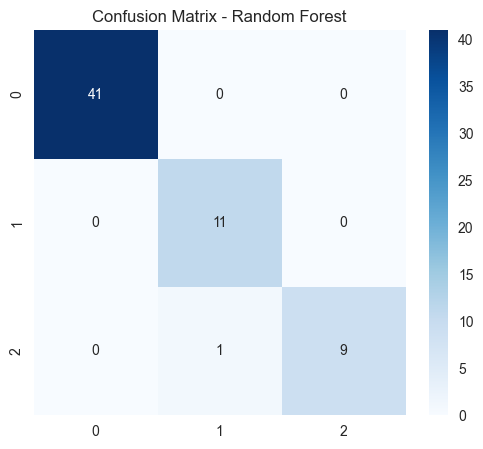


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        41
           1       0.71      0.91      0.80        11
           2       0.89      0.80      0.84        10

    accuracy                           0.92        62
   macro avg       0.87      0.89      0.87        62
weighted avg       0.93      0.92      0.92        62



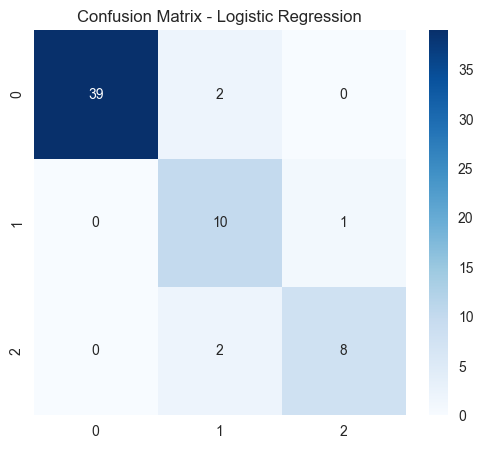

In [18]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

results = {}

print("\n=== HASIL MODELING ===")

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results[name] = {"Accuracy": round(acc, 4), "F1-Score": round(f1, 4)}
    
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))
    
    plt.figure(figsize=(6,5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()


=== PERBANDINGAN PERFORMA MODEL ===
                     Accuracy  F1-Score
Random Forest          0.9839    0.9838
Logistic Regression    0.9194    0.9225


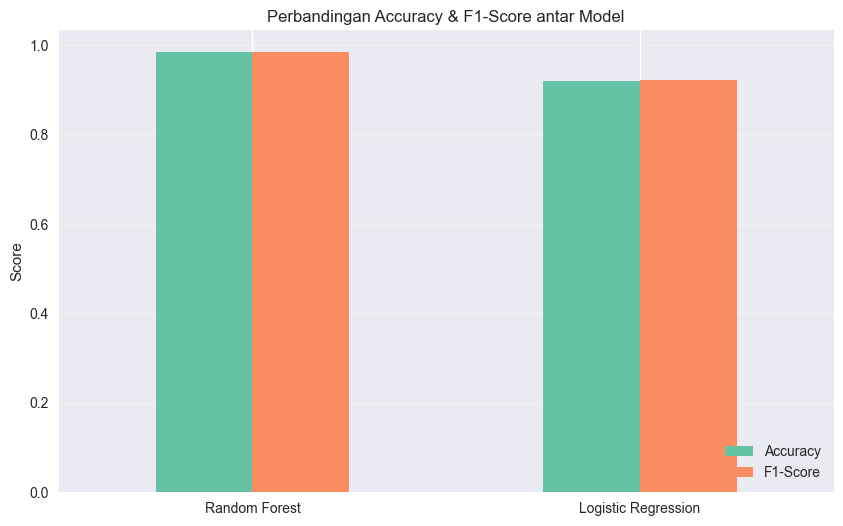

In [19]:
# Tabel Perbandingan Model
comparison = pd.DataFrame(results).T
print("\n=== PERBANDINGAN PERFORMA MODEL ===")
print(comparison)

# Visualisasi perbandingan (bar chart)
comparison.plot(kind='bar', figsize=(10, 6))
plt.title('Perbandingan Accuracy & F1-Score antar Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.show()


=== FEATURE IMPORTANCE - RANDOM FOREST ===
Stunting_Prevalence         0.5979
Urban_Population_Percent    0.1148
Poverty_Rate                0.0992
Fertility_Rate              0.0935
GDP_per_Capita              0.0685
Male_Literacy_Rate          0.0260
dtype: float64


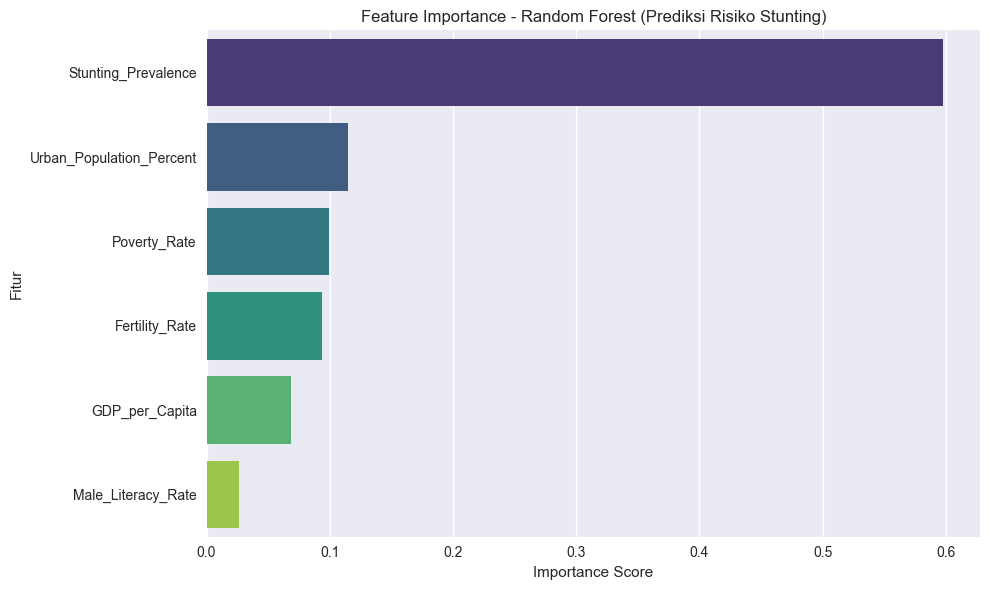

In [21]:
#  FEATURE IMPORTANCE

# Feature Importance dari Random Forest (model terbaik)
rf_model = models["Random Forest"]  # ambil model Random Forest yang sudah dilatih

importances = pd.Series(rf_model.feature_importances_, 
                        index=X.columns).sort_values(ascending=False)

print("\n=== FEATURE IMPORTANCE - RANDOM FOREST ===")
print(importances.round(4))

# Visualisasi Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance - Random Forest (Prediksi Risiko Stunting)')
plt.xlabel('Importance Score')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

In [22]:
pip install streamlit pandas scikit-learn imbalanced-learn joblib

   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.2 MB 806.1 kB/s eta 0:00:11
   -- ------------------------------------- 0.5/9.2 MB 806.1 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/9.2 MB 669.5 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/9.2 MB 669.5 kB/s eta 0:00:13
   ---- ----------------------------------- 1.0/9.2 MB 742.4 kB/s eta 0:00:11
   ---- ----------------------------------- 1.0/9.2 MB 742.4 kB/s eta 0:00:11
   ----- ---------------------------------- 1.3/9.2 MB 666.5 kB/s eta 0:00:12
   ------ --------------------------------- 1.6/9.2 MB 741.7 kB/s eta 0:00:11
   ------- -------------------------------- 1.8/9.2 MB 779.0 kB/s eta 0:00:10
   ------- -------------------------------- 1.8/9.2 MB 779.0 kB/s eta 0:00:10
   ----------

In [23]:
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# NORMALISASI
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# RANDOM FOREST FINAL
rf_final = RandomForestClassifier(
    random_state=42
)

rf_final.fit(X_train_scaled, y_train_res)

# SAVE
joblib.dump(rf_final,'rf_model.pkl')
joblib.dump(scaler,'scaler.pkl')

print("Model & scaler saved")

Model & scaler saved


#### Penjelasan:
Pada tahap ini dilakukan pembangunan model klasifikasi untuk memprediksi tingkat risiko stunting (Stunting_Risk: 0 = Rendah, 1 = Sedang, 2 = Tinggi). Karena distribusi kelas target sangat tidak seimbang (imbalanced), digunakan teknik SMOTE (Synthetic Minority Over-sampling Technique) untuk menyeimbangkan data latih.
Tiga algoritma yang dibandingkan adalah:

- Random Forest (ensemble berbasis decision tree)
- Gradient Boosting (ensemble berbasis boosting)
- Logistic Regression (model linear baseline)

Metrik evaluasi yang digunakan:

- Accuracy
- F1-Score (weighted average, karena data masih sensitif terhadap imbalance)
- Confusion Matrix untuk melihat kesalahan prediksi antar kelas

### Conclusion

Analisis ini menunjukkan bahwa Stunting_Prevalence adalah prediktor paling kuat terhadap risiko stunting. Faktor risiko utama adalah kemiskinan dan fertilitas tinggi, sedangkan literasi perempuan, urbanisasi, dan GDP per kapita berperan sebagai faktor pelindung.
Model Random Forest setelah SMOTE memberikan performa terbaik. Hasil ini mendukung rekomendasi kebijakan: prioritaskan pendidikan perempuan, pengentasan kemiskinan, dan perencanaan keluarga.

----

**Anggota Kelompok:**
- [Patricia Felisca Clarrisya | 00000117495]
- [Lovely Sayungki | 00000121376]
- [Evan Marcello Sabastian | 00000122364]

**Kelas:** BL